# Invariant Generator Training Analysis

Use this notebook after a training run to inspect loss trends, test metrics, gradient flow, the sparse invariant encoder `S`, and learned structural tensors `a`/`A`. Update the paths in the first code cell if you trained with a different config or `run_id`.

Loss terms: `data` fits predicted yield value to the target, `param` is MLP weight regularization, `structure` keeps trainable structure tensors normalized, and `encoder` regularizes the sparse encoder matrix `S`.

If plotting dependencies are missing, install them with `uv add --dev matplotlib notebook` from the project root.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RUN_DIR = PROJECT_ROOT / "results" / "rotatedhill"
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.toml"
CHECKPOINT_PATH = RUN_DIR / "checkpoint_best.pt"
HISTORY_PATH = RUN_DIR / "history.json"

sys.path.insert(0, str(PROJECT_ROOT / "src"))
MPLCONFIGDIR = PROJECT_ROOT / ".matplotlib-cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

print("project:", PROJECT_ROOT)
print("run dir:", RUN_DIR)
print("config:", CONFIG_PATH)
print("checkpoint:", CHECKPOINT_PATH)
print("history:", HISTORY_PATH)

project: /mimer/NOBACKUP/groups/naiss2026-4-599/projects/symbolic regression/Invariant-Generator
run dir: /mimer/NOBACKUP/groups/naiss2026-4-599/projects/symbolic regression/Invariant-Generator/results/rotatedhill
config: /mimer/NOBACKUP/groups/naiss2026-4-599/projects/symbolic regression/Invariant-Generator/configs/default.toml
checkpoint: /mimer/NOBACKUP/groups/naiss2026-4-599/projects/symbolic regression/Invariant-Generator/results/rotatedhill/checkpoint_best.pt
history: /mimer/NOBACKUP/groups/naiss2026-4-599/projects/symbolic regression/Invariant-Generator/results/rotatedhill/history.json


In [2]:
import json
from pprint import pprint

import numpy as np
import torch

try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")
except NameError:
    pass

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError(
        "matplotlib is required for this notebook. Install it with: "
        "uv add --dev matplotlib notebook"
    ) from exc

from invariant_generator.config import load_config
from invariant_generator.data import prepare_training_data
from invariant_generator.evaluation import evaluate_model, predict_numpy
from invariant_generator.model import InvariantYieldModel

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

In [3]:
with HISTORY_PATH.open("r", encoding="utf-8") as f:
    payload = json.load(f)

history = payload.get("history", [])
if not history:
    raise ValueError(f"No history rows found in {HISTORY_PATH}")

epochs = np.array([row["epoch"] for row in history], dtype=float)
# print("history rows:", len(history))
# print("first epoch:", history[0]["epoch"], "last epoch:", history[-1]["epoch"])
# print("top-level keys:")
# pprint(sorted(payload.keys()))
# print("history keys:")
# pprint(sorted(history[-1].keys()))

In [4]:
parameter_counts = payload.get("parameter_counts")
if parameter_counts is None:
    print("No parameter_counts in history.json; load the checkpoint/model below for counts.")
else:
    pprint(parameter_counts)

{'encoder_total': 52,
 'encoder_trainable': 52,
 'invariant_pool_total': 90,
 'invariant_pool_trainable': 90,
 'regressor_total': 4545,
 'regressor_trainable': 4545,
 'total': 4687,
 'trainable': 4687}


In [5]:
def series(name, default=np.nan):
    return np.array([row.get(name, default) for row in history], dtype=float)

def available(name):
    return any(name in row for row in history)

def positive_for_log(values):
    values = np.asarray(values, dtype=float)
    return np.isfinite(values).all() and np.nanmin(values) > 0.0

def plot_lines(ax, specs, title, ylabel="loss"):
    plotted = False
    for key, label in specs:
        if available(key):
            values = series(key)
            ax.plot(epochs, values, marker="o", linewidth=1.6, label=label)
            plotted = True
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    if plotted:
        ax.legend()
        all_values = np.concatenate([series(key) for key, _ in specs if available(key)])
        if positive_for_log(all_values):
            ax.set_yscale("log")
    else:
        ax.text(0.5, 0.5, "not available", ha="center", va="center", transform=ax.transAxes)

LOSS_TERMS = [
    ("total", "total"),
    ("data", "data fit"),
    ("param", "MLP param reg"),
    ("structure", "structure reg"),
    ("encoder", "encoder reg"),
]

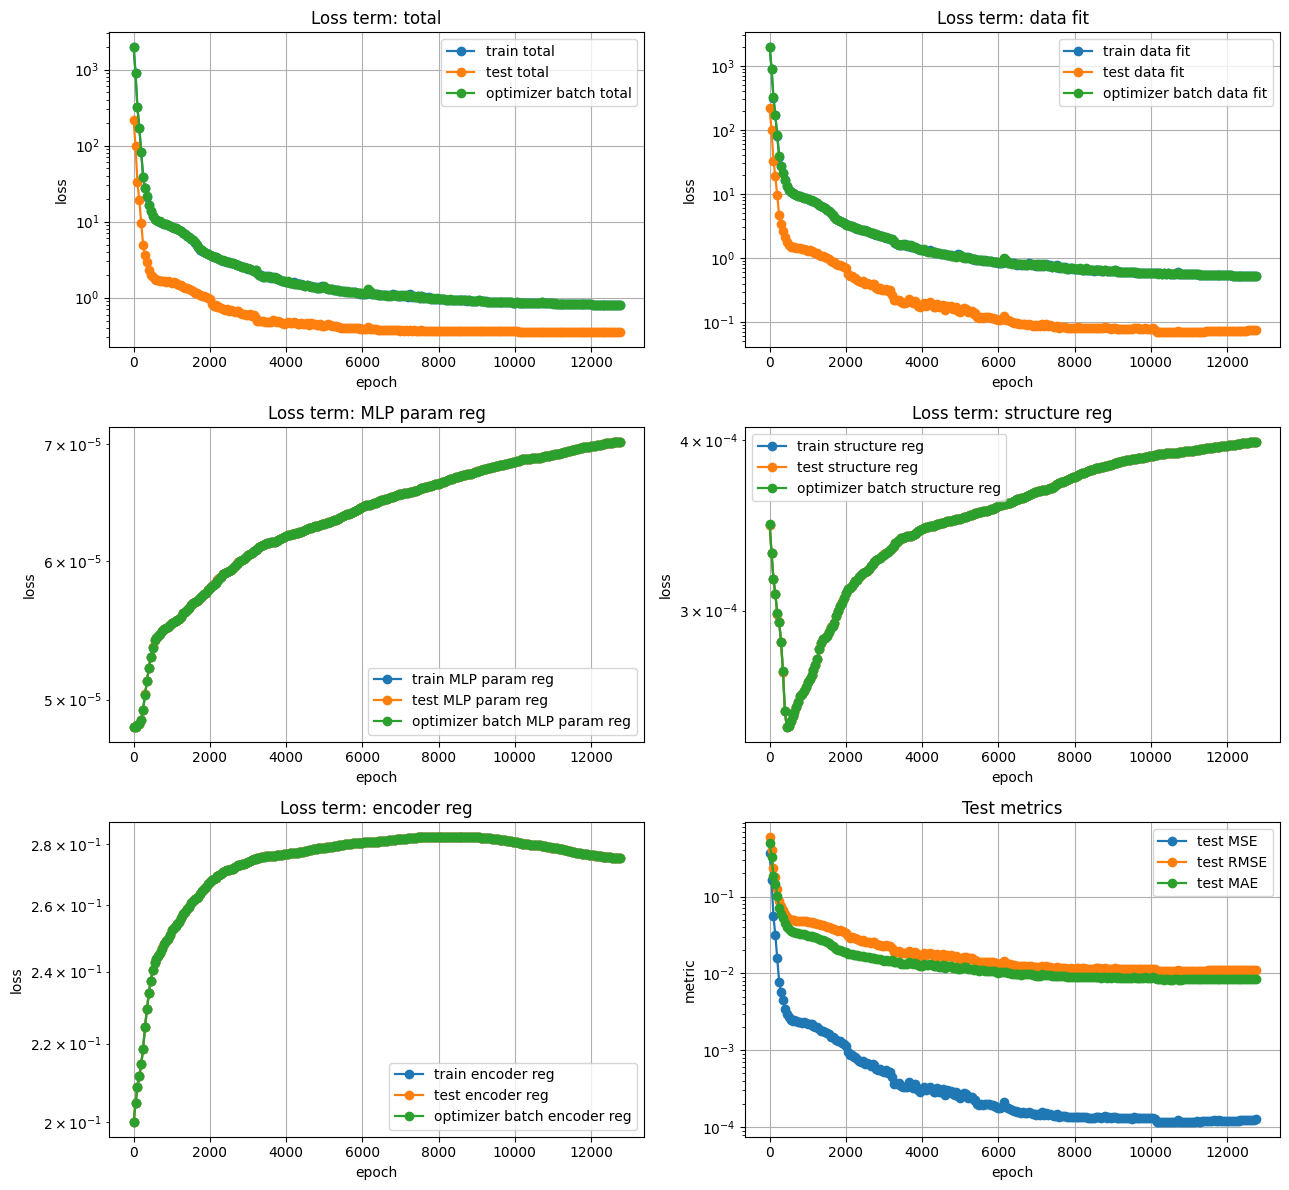

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(13, 12))

for ax, (suffix, label) in zip(axes.flat[:5], LOSS_TERMS):
    plot_lines(
        ax,
        [
            (f"train_loss_{suffix}", f"train {label}"),
            (f"test_loss_{suffix}", f"test {label}"),
            (f"loss_{suffix}", f"optimizer batch {label}"),
        ],
        f"Loss term: {label}",
    )

plot_lines(
    axes.flat[5],
    [("test_mse", "test MSE"), ("test_rmse", "test RMSE"), ("test_mae", "test MAE")],
    "Test metrics",
    ylabel="metric",
)

fig.tight_layout()
plt.show()

In [7]:
def summarize_change(key):
    if not available(key):
        return None
    values = series(key)
    first = values[0]
    last = values[-1]
    change = last - first
    rel = change / first if np.isfinite(first) and first != 0.0 else np.nan
    return {"first": first, "last": last, "delta": change, "relative_delta": rel}

def print_loss_change_table(prefix):
    rows = []
    for suffix, label in LOSS_TERMS:
        key = f"{prefix}_loss_{suffix}"
        summary = summarize_change(key)
        if summary is None:
            continue
        rows.append((label, summary["first"], summary["last"], summary["delta"], summary["relative_delta"]))
    if not rows:
        print(f"No {prefix} loss-term history found.")
        return
    print(f"{prefix.upper()} loss-term changes")
    print(f"{'term':<16} {'first':>14} {'last':>14} {'delta':>14} {'rel_delta':>12}")
    for label, first, last, delta, rel in rows:
        print(f"{label:<16} {first:14.6g} {last:14.6g} {delta:14.6g} {rel:12.3%}")
    print()

print_loss_change_table("train")
print_loss_change_table("test")

for key in ["test_mse", "test_rmse", "test_mae"]:
    summary = summarize_change(key)
    if summary is not None:
        print(key)
        pprint(summary)

if available("grad_norm_encoder"):
    print("encoder grad norm min/max:", float(np.nanmin(series("grad_norm_encoder"))), float(np.nanmax(series("grad_norm_encoder"))))

TRAIN loss-term changes
term                      first           last          delta    rel_delta
total                   1975.86       0.799437       -1975.06     -99.960%
data fit                1975.66       0.523699       -1975.14     -99.973%
MLP param reg       4.82017e-05    7.02333e-05    2.20316e-05      45.707%
structure reg       0.000346356    0.000398907    5.25514e-05      15.173%
encoder reg             0.20012        0.27527      0.0751496      37.552%

TEST loss-term changes
term                      first           last          delta    rel_delta
total                     218.5       0.351195       -218.149     -99.839%
data fit                  218.3      0.0754562       -218.224     -99.965%
MLP param reg       4.82017e-05    7.02333e-05    2.20316e-05      45.707%
structure reg       0.000346356    0.000398907    5.25514e-05      15.173%
encoder reg             0.20012        0.27527      0.0751496      37.552%

test_mse
{'delta': np.float64(-0.3637068407009274),

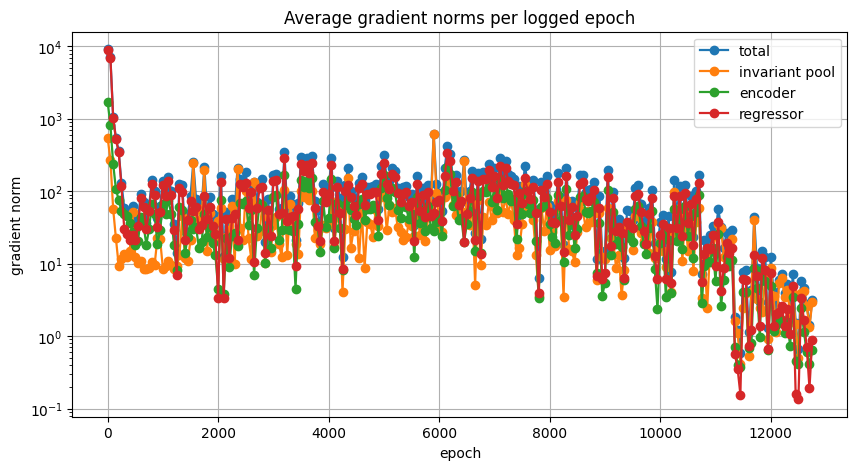

In [8]:
grad_specs = [
    ("grad_norm_total", "total"),
    ("grad_norm_invariant_pool", "invariant pool"),
    ("grad_norm_encoder", "encoder"),
    ("grad_norm_regressor", "regressor"),
]
fig, ax = plt.subplots(figsize=(10, 5))
plot_lines(ax, grad_specs, "Average gradient norms per logged epoch", ylabel="gradient norm")
plt.show()

In [9]:
from dataclasses import fields, is_dataclass
from pathlib import Path
from invariant_generator.config import Config


def config_from_checkpoint(checkpoint_payload, fallback_path):
    saved_config = checkpoint_payload.get("config")
    if not isinstance(saved_config, dict):
        print("No config saved in checkpoint; using CONFIG_PATH.")
        return load_config(fallback_path)

    restored = Config()
    for section_name, values in saved_config.items():
        if section_name.startswith("_") or not hasattr(restored, section_name):
            continue
        section = getattr(restored, section_name)
        if not is_dataclass(section) or not isinstance(values, dict):
            continue

        known_fields = {field.name for field in fields(section)}
        for key, value in values.items():
            if key not in known_fields:
                continue
            current = getattr(section, key)
            if isinstance(current, Path) and value is not None:
                value = Path(value)
            elif isinstance(current, tuple) and isinstance(value, list):
                value = tuple(value)
            setattr(section, key, value)

    print("Using config stored in checkpoint.")
    return restored


device = torch.device("cpu")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
config = config_from_checkpoint(checkpoint, CONFIG_PATH)

model = InvariantYieldModel.from_config(config).to(device)
load_result = model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("checkpoint epoch:", checkpoint.get("epoch"))
print("selected invariants:", config.invariants.selected)
print("checkpoint metrics:")
pprint(checkpoint.get("metrics", {}))
print("load result:", load_result)
print("model parameter counts:")
pprint(model.parameter_counts())

Using config stored in checkpoint.
checkpoint epoch: 10750
selected invariants: ['I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13']
checkpoint metrics:
{'mae': 0.008295460887308011,
 'max_abs_error': 0.054502010345458984,
 'mse': 0.00011494291964028303,
 'rmse': 0.01072114357894171,
 'sse': 0.06896575178416982}
load result: <All keys matched successfully>
model parameter counts:
{'encoder_total': 52,
 'encoder_trainable': 52,
 'invariant_pool_total': 90,
 'invariant_pool_trainable': 90,
 'regressor_total': 4545,
 'regressor_trainable': 4545,
 'total': 4687,
 'trainable': 4687}


## Structural Tensor Diagnostics

These cells inspect the learned trainable structure tensors from the checkpoint. For the second-order tensor `a`, the symmetric part `s` gives preferred material directions through its eigenvectors, while the skew part `w` captures the antisymmetric component used by invariants such as `I8`, `I9`, and `I10`. For the fourth-order tensor `A`, the effective symmetrized tensor is visualized in a Voigt-style `6 x 6` matrix so the anisotropic quadratic form behind `I11 = sigma : A : sigma` is easier to read.


raw_a: shape=(3, 3)  norm=1.24359  min=-0.63804  max=0.944678
s = 0.5 * (a + a.T): shape=(3, 3)  norm=1.03156  min=-0.63804  max=0.480539
w = 0.5 * (a - a.T): shape=(3, 3)  norm=0.694539  min=-0.46414  max=0.46414
antisymmetric check max(abs(w + w.T)): 0.0

eigenpairs of symmetric part s, sorted by abs(eigenvalue):
  lambda=-0.720567  direction=[ 0.328  -0.9181 -0.2225]
  lambda= 0.710368  direction=[0.6191 0.031  0.7847]
  lambda=-0.200702  direction=[ 0.7135  0.3951 -0.5786]


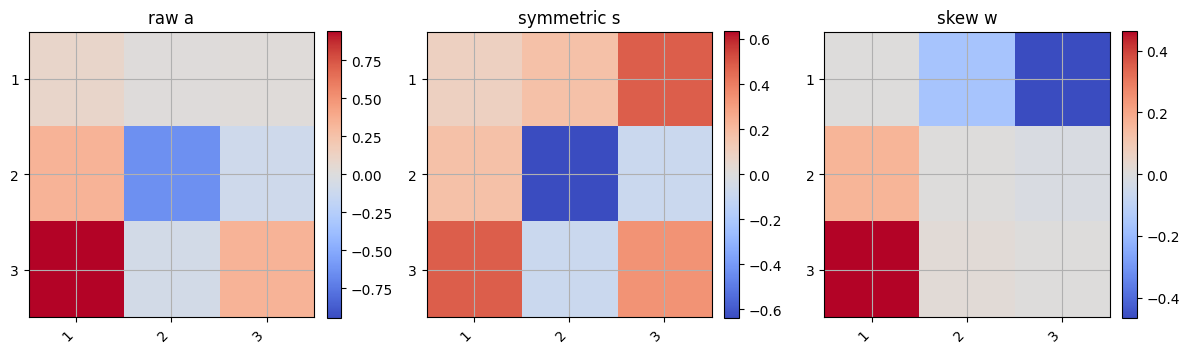

effective symmetrized A: shape=(3, 3, 3, 3)  norm=0.423435  min=-0.130598  max=0.160935
A as diagnostic 6x6 Voigt matrix: shape=(6, 6)  norm=0.402201  min=-0.130598  max=0.160935
Voigt symmetry check max(abs(A - A.T)): 1.4901161193847656e-08
Note: this is a simple component map, not engineering-shear-scaled Voigt notation.

leading eigenmodes of symmetrized A Voigt matrix:
  lambda= 0.292911  11:-0.698, 33:+0.688, 13:-0.155
  lambda= 0.260246  11:+0.325, 22:-0.826, 33:+0.423
  lambda=-0.082505  11:+0.574, 22:+0.440, 33:+0.531, 23:-0.383, 13:-0.218
  lambda=-0.0350036  11:+0.153, 22:+0.222, 23:+0.731, 13:-0.415, 12:-0.470
  lambda=-0.0121713  11:+0.155, 22:+0.256, 33:+0.255, 23:+0.424, 13:+0.805
  lambda= 0.0077964  11:-0.174, 23:-0.352, 13:+0.325, 12:-0.857


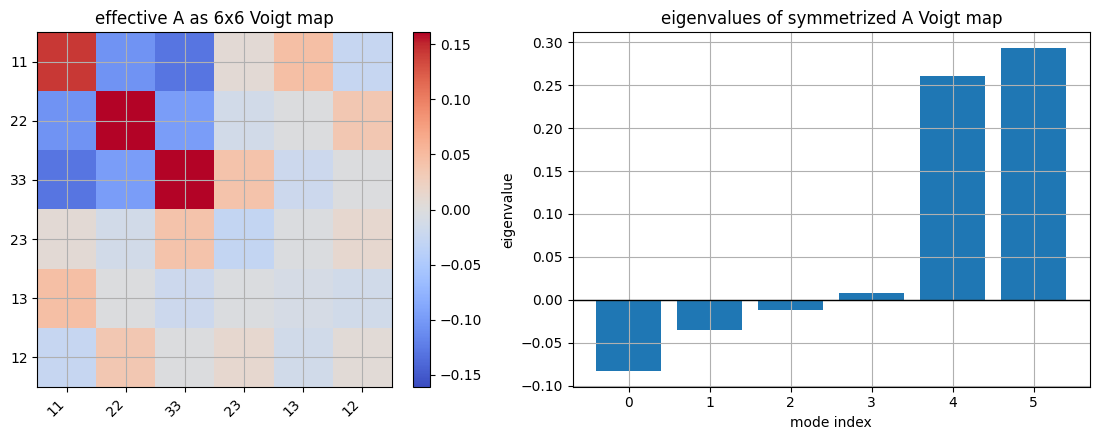

In [10]:
pool = model.invariant_pool
VOIGT_PAIRS = [(0, 0), (1, 1), (2, 2), (1, 2), (0, 2), (0, 1)]
VOIGT_LABELS = ["11", "22", "33", "23", "13", "12"]


def tensor_np(tensor):
    return tensor.detach().cpu().numpy()


def symmetric_limits(values):
    max_abs = float(np.nanmax(np.abs(values))) if np.size(values) else 1.0
    max_abs = max(max_abs, 1e-12)
    return -max_abs, max_abs


def plot_heatmap(ax, values, title, *, xlabels=None, ylabels=None):
    vmin, vmax = symmetric_limits(values)
    image = ax.imshow(values, cmap="coolwarm", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    if xlabels is not None:
        ax.set_xticks(np.arange(len(xlabels)))
        ax.set_xticklabels(xlabels, rotation=45, ha="right")
    if ylabels is not None:
        ax.set_yticks(np.arange(len(ylabels)))
        ax.set_yticklabels(ylabels)
    return image


def fourth_order_to_voigt(A):
    A_np = tensor_np(A)
    A_voigt = np.zeros((6, 6), dtype=float)
    for row, (i, j) in enumerate(VOIGT_PAIRS):
        for col, (k, l) in enumerate(VOIGT_PAIRS):
            A_voigt[row, col] = A_np[i, j, k, l]
    return A_voigt


def print_matrix_stats(name, values):
    values = np.asarray(values, dtype=float)
    print(
        f"{name}: shape={values.shape}  "
        f"norm={np.linalg.norm(values):.6g}  "
        f"min={values.min():.6g}  max={values.max():.6g}"
    )


raw_a = getattr(pool, "raw_a", None)
if raw_a is None:
    print("Second-order structure tensor a is disabled for this model.")
else:
    s, w = pool.effective_second_order_parts()
    raw_a_np = tensor_np(raw_a)
    s_np = tensor_np(s)
    w_np = tensor_np(w)

    print_matrix_stats("raw_a", raw_a_np)
    print_matrix_stats("s = 0.5 * (a + a.T)", s_np)
    print_matrix_stats("w = 0.5 * (a - a.T)", w_np)
    print("antisymmetric check max(abs(w + w.T)):", np.max(np.abs(w_np + w_np.T)))

    eigvals, eigvecs = np.linalg.eigh(s_np)
    order = np.argsort(np.abs(eigvals))[::-1]
    print("\neigenpairs of symmetric part s, sorted by abs(eigenvalue):")
    for idx in order:
        direction = eigvecs[:, idx]
        print(f"  lambda={eigvals[idx]: .6g}  direction={np.array2string(direction, precision=4)}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    for ax, values, title in zip(
        axes,
        [raw_a_np, s_np, w_np],
        ["raw a", "symmetric s", "skew w"],
    ):
        image = plot_heatmap(ax, values, title, xlabels=["1", "2", "3"], ylabels=["1", "2", "3"])
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


raw_A = getattr(pool, "raw_A", None)
if raw_A is None:
    print("Fourth-order structure tensor A is disabled for this model.")
else:
    A = pool.effective_fourth_order_tensor()
    A_np = tensor_np(A)
    A_voigt = fourth_order_to_voigt(A)
    A_voigt_sym = 0.5 * (A_voigt + A_voigt.T)

    print_matrix_stats("effective symmetrized A", A_np)
    print_matrix_stats("A as diagnostic 6x6 Voigt matrix", A_voigt)
    print("Voigt symmetry check max(abs(A - A.T)):", np.max(np.abs(A_voigt - A_voigt.T)))
    print("Note: this is a simple component map, not engineering-shear-scaled Voigt notation.")

    eigvals, eigvecs = np.linalg.eigh(A_voigt_sym)
    order = np.argsort(np.abs(eigvals))[::-1]
    print("\nleading eigenmodes of symmetrized A Voigt matrix:")
    for idx in order[: min(6, len(order))]:
        vector = eigvecs[:, idx]
        active = [
            f"{label}:{value:+.3f}"
            for label, value in zip(VOIGT_LABELS, vector)
            if abs(value) >= 0.15
        ]
        print(f"  lambda={eigvals[idx]: .6g}  " + ", ".join(active))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    image = plot_heatmap(
        axes[0],
        A_voigt,
        "effective A as 6x6 Voigt map",
        xlabels=VOIGT_LABELS,
        ylabels=VOIGT_LABELS,
    )
    fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].bar(np.arange(len(eigvals)), eigvals)
    axes[1].axhline(0.0, color="black", linewidth=1)
    axes[1].set_title("eigenvalues of symmetrized A Voigt map")
    axes[1].set_xlabel("mode index")
    axes[1].set_ylabel("eigenvalue")
    fig.tight_layout()
    plt.show()


S shape: (4, 13)
columns close to zero threshold: 0.001
    I9  col_l1=0.165657  col_l2=0.146636 
   I12  col_l1=0.171125  col_l2=0.0899347 
    I6  col_l1=0.204712  col_l2=0.117448 
   I13  col_l1=0.262865  col_l2=0.210306 
    I7  col_l1=0.321711  col_l2=0.184248 
   I11  col_l1=0.359132  col_l2=0.219025 
   I10  col_l1=0.404025  col_l2=0.245282 
    I5  col_l1=0.409298  col_l2=0.255759 
    I8  col_l1=0.542705  col_l2=0.323545 
    I4  col_l1=1.01833  col_l2=0.859271 
    I1  col_l1=1.04131  col_l2=1.01174 
    I3  col_l1=1.1792  col_l2=1.08951 
    I2  col_l1=1.25914  col_l2=1.04859 


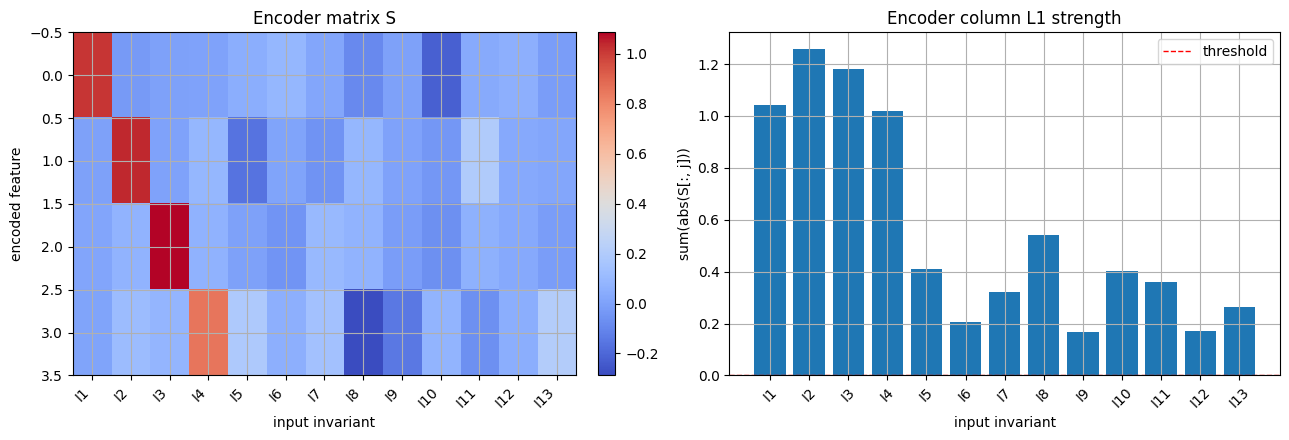

In [11]:
S = model.encoder_matrix()
invariant_names = list(config.invariants.selected)
ENCODER_ZERO_THRESHOLD = 1e-3

if S is None:
    print("Encoder is disabled for this run.")
else:
    S_np = S.detach().cpu().numpy()
    abs_S = np.abs(S_np)
    col_l1 = abs_S.sum(axis=0)
    col_l2 = np.sqrt((S_np ** 2).sum(axis=0))
    order = np.argsort(col_l1)

    print("S shape:", S_np.shape)
    print("columns close to zero threshold:", ENCODER_ZERO_THRESHOLD)
    for idx in order:
        flag = "LOW" if col_l1[idx] <= ENCODER_ZERO_THRESHOLD else ""
        print(f"{invariant_names[idx]:>6s}  col_l1={col_l1[idx]:.6g}  col_l2={col_l2[idx]:.6g} {flag}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    image = axes[0].imshow(S_np, aspect="auto", cmap="coolwarm")
    axes[0].set_title("Encoder matrix S")
    axes[0].set_xlabel("input invariant")
    axes[0].set_ylabel("encoded feature")
    axes[0].set_xticks(np.arange(len(invariant_names)))
    axes[0].set_xticklabels(invariant_names, rotation=45, ha="right")
    fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].bar(invariant_names, col_l1)
    axes[1].axhline(ENCODER_ZERO_THRESHOLD, color="red", linestyle="--", linewidth=1, label="threshold")
    axes[1].set_title("Encoder column L1 strength")
    axes[1].set_xlabel("input invariant")
    axes[1].set_ylabel("sum(abs(S[:, j]))")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend()
    fig.tight_layout()
    plt.show()

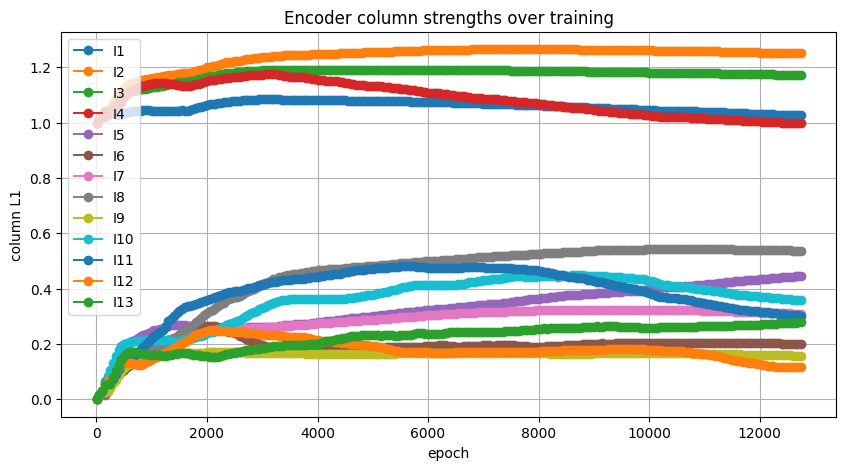

In [12]:
if S is not None:
    col_keys = [f"encoder_col_l1_{name}" for name in invariant_names]
    if any(available(key) for key in col_keys):
        fig, ax = plt.subplots(figsize=(10, 5))
        for name, key in zip(invariant_names, col_keys):
            if available(key):
                ax.plot(epochs, series(key), marker="o", linewidth=1.4, label=name)
        ax.set_title("Encoder column strengths over training")
        ax.set_xlabel("epoch")
        ax.set_ylabel("column L1")
        ax.legend()
        plt.show()
    else:
        print("Encoder column history is not available. Re-run training with the updated logger.")

In [13]:
try:
    data = prepare_training_data(config)
    print("train:", data.X_train.shape, "test:", data.X_test.shape)
except Exception as exc:
    data = None
    print("Could not load prepared data. Prediction/invariant diagnostics are skipped.")
    print(type(exc).__name__, exc)

train: (5400, 6) test: (600, 6)


raw invariant feature summary
      I1  mean= 2.7269e+00  std= 1.9217e+00  min= 1.9380e-01  max= 3.1970e+01
      I2  mean= 3.6728e+00  std= 1.3114e+00  min= 1.4073e+00  max= 1.8975e+01
      I3  mean= 3.3279e+00  std= 1.2312e+00  min= 1.0216e+00  max= 1.6230e+01
      I4  mean= 1.1646e+00  std= 8.1621e-01  min=-1.9823e+00  max= 3.9762e+00
      I5  mean= 1.3577e+00  std= 8.3969e-01  min=-5.2323e-02  max= 1.1082e+01
      I6  mean= 1.4867e+00  std= 1.0635e+00  min=-2.8742e+00  max= 6.1477e+00
      I7  mean= 2.4131e+00  std= 8.6791e-01  min= 8.5654e-01  max= 1.1055e+01
      I8  mean=-6.1661e-01  std= 3.4792e-01  min=-5.3026e+00  max=-6.0465e-02
      I9  mean=-1.6375e+00  std= 5.9054e-01  min=-7.8729e+00  max=-4.5897e-01
     I10  mean=-5.7294e-02  std= 5.6945e-01  min=-1.1570e+00  max= 1.2964e+00
     I11  mean=-1.6402e-01  std= 4.6241e-01  min=-4.6028e+00  max= 1.4098e+00
     I12  mean=-2.9636e-01  std= 7.4876e-01  min=-6.0409e+00  max= 1.9768e+00
     I13  mean=-3.5767e-01  std= 1

/local/tmp.9698980/ipykernel_2111790/1196945102.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([invariant_values[:, i] for i in range(invariant_values.shape[1])], labels=invariant_names)


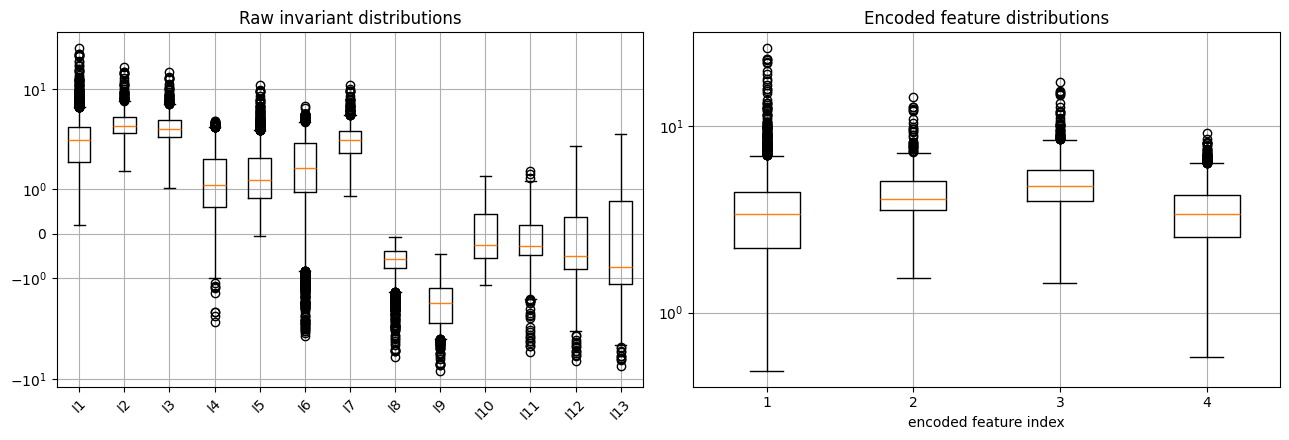

In [14]:
def print_feature_summary(names, values):
    values = np.asarray(values, dtype=float)
    for idx, name in enumerate(names):
        column = values[:, idx]
        print(
            f"{name:>8s}  mean={column.mean(): .4e}  std={column.std(): .4e}  "
            f"min={column.min(): .4e}  max={column.max(): .4e}"
        )

if data is not None:
    with torch.no_grad():
        X_sample = torch.as_tensor(data.X_train[: min(5000, len(data.X_train))], dtype=torch.float32)
        invariant_values = model.invariant_pool(X_sample).cpu().numpy()
        encoded_values = model.invariant_features(X_sample).cpu().numpy()

    print("raw invariant feature summary")
    print_feature_summary(invariant_names, invariant_values)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].boxplot([invariant_values[:, i] for i in range(invariant_values.shape[1])], labels=invariant_names)
    axes[0].set_title("Raw invariant distributions")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].set_yscale("symlog")

    axes[1].boxplot([encoded_values[:, i] for i in range(encoded_values.shape[1])])
    axes[1].set_title("Encoded feature distributions")
    axes[1].set_xlabel("encoded feature index")
    axes[1].set_yscale("symlog")
    fig.tight_layout()
    plt.show()

{'mae': 0.008295466301396577,
 'max_abs_error': 0.054502010345458984,
 'mse': 0.00011494314241908542,
 'rmse': 0.010721153968630681,
 'sse': 0.06896588545145126}


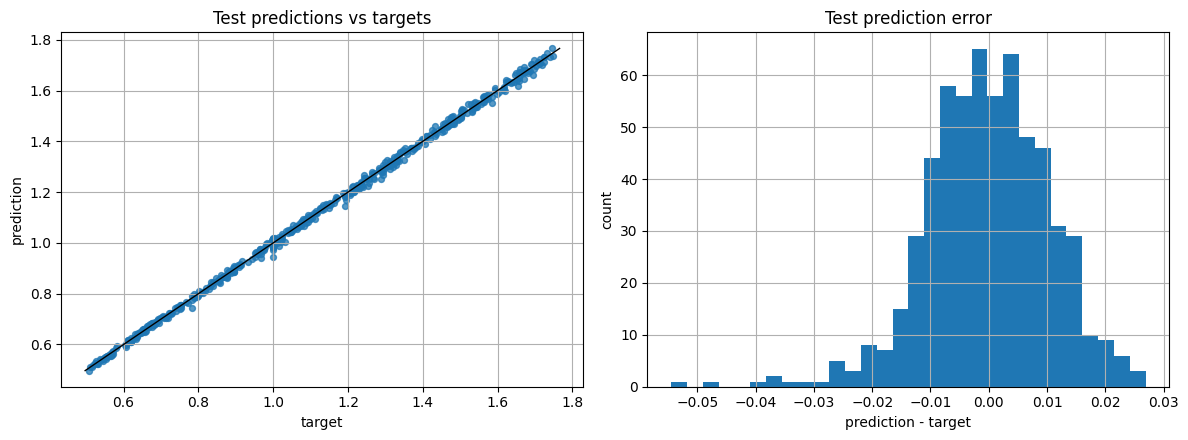

In [15]:
if data is not None:
    metrics = evaluate_model(model, data.X_test, data.y_test, device=device, batch_size=8192)
    pprint(metrics)
    y_pred = predict_numpy(model, data.X_test, device=device, batch_size=8192)
    y_true = data.y_test
    error = y_pred - y_true

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].scatter(y_true, y_pred, s=18, alpha=0.75)
    low = min(float(y_true.min()), float(y_pred.min()))
    high = max(float(y_true.max()), float(y_pred.max()))
    axes[0].plot([low, high], [low, high], color="black", linewidth=1)
    axes[0].set_title("Test predictions vs targets")
    axes[0].set_xlabel("target")
    axes[0].set_ylabel("prediction")

    axes[1].hist(error, bins=30)
    axes[1].set_title("Test prediction error")
    axes[1].set_xlabel("prediction - target")
    axes[1].set_ylabel("count")
    fig.tight_layout()
    plt.show()